# Pareto Sampling Report

This notebook reads one or more `points.csv` files produced by `src/sample_exp.py`, builds Pareto fronts for every sampled run, and compares selected experiments.

Expected `points.csv` columns:

- `circuit`
- `run_id`
- `size`
- `depth`

Rows with missing `run_id` are treated as the original circuit point and are used for normalization.

In [1]:
from __future__ import annotations

from itertools import product
from pathlib import Path
from statistics import fmean, pstdev

import pandas as pd

pd.set_option("display.max_rows", 200)
pd.set_option("display.max_columns", 50)

## Inputs

Set `points_csv_paths` to the `points.csv` files you want to compare. By default, `run_name` is inferred from the parent experiment directory name.

In [2]:
# Fill this list with paths to points.csv files produced by src/sample_exp.py.
points_csv_paths = [
    # "../outputs/2026-05-26/12:06_tb_zhu_i10_79035/points.csv",
]

output_dir = Path('../outputs')
points_csv_paths = list(filter(lambda p: p.name == 'points.csv', output_dir.glob('**/*.csv')))
print(len(points_csv_paths))

# Optional friendly labels. If a path is missing here, its parent directory name is used.
run_name_overrides = {
    # "../outputs/2026-05-26/12:06_tb_zhu_i10_79035/points.csv": "gflownet_tb",
}
run_name_overrides = {str(p): '_'.join(p.parent.name.split('_')[1:-1]) for p in points_csv_paths}
print(run_name_overrides)

38
{'../outputs/2026-06-02/16:02:05_drills_apex1_81837/points.csv': 'drills_apex1', '../outputs/2026-06-02/00:23:02_tbzhuDOP_dalu_81414/points.csv': 'tbzhuDOP_dalu', '../outputs/2026-06-02/16:28:57_drillsDOP_c5315_81838/points.csv': 'drillsDOP_c5315', '../outputs/2026-06-02/15:35:04_drillsDOP_bc0_81838/points.csv': 'drillsDOP_bc0', '../outputs/2026-06-02/15:57:50_drillsDOP_apex1_81838/points.csv': 'drillsDOP_apex1', '../outputs/2026-06-02/16:59:47_drillsDOP_dalu_81838/points.csv': 'drillsDOP_dalu', '../outputs/2026-06-02/15:37:05_drills_bc0_81837/points.csv': 'drills_bc0', '../outputs/2026-06-02/17:33:24_drills_k2_81837/points.csv': 'drills_k2', '../outputs/2026-06-02/01:49:15_tbzhuLinear_k2_81413/points.csv': 'tbzhuLinear_k2', '../outputs/2026-06-02/00:21:33_tbzhuLinear_dalu_81413/points.csv': 'tbzhuLinear_dalu', '../outputs/2026-06-02/15:17:57_drills_c1355_81837/points.csv': 'drills_c1355', '../outputs/2026-06-02/01:51:19_tbzhuDOP_k2_81414/points.csv': 'tbzhuDOP_k2', '../outputs/2026

## Pareto Helpers

The notebook minimizes normalized `(size, depth)`, where the original circuit is `(1, 1)`. Hypervolume is the area dominated by the Pareto front and bounded by the original circuit reference point.

In [3]:
def weakly_dominates_min(a, b):
    """Return True when point a weakly dominates point b in minimization space."""
    return a[0] <= b[0] and a[1] <= b[1]


def strictly_dominates_min(a, b):
    return weakly_dominates_min(a, b) and (a[0] < b[0] or a[1] < b[1])


def pareto_front_min(points):
    """Deduplicated nondominated points for 2D minimization."""
    unique_points = sorted(set((float(x), float(y)) for x, y in points), key=lambda p: (p[0], p[1]))
    return [
        point
        for point in unique_points
        if not any(strictly_dominates_min(other, point) for other in unique_points)
    ]


def hypervolume_min_2d(points, reference=(1.0, 1.0)):
    """2D minimization hypervolume relative to the original circuit point."""
    front = pareto_front_min(points)
    clipped = sorted(
        {
            (max(0.0, min(reference[0], x)), max(0.0, min(reference[1], y)))
            for x, y in front
            if x < reference[0] and y < reference[1]
        },
        key=lambda p: p[0],
    )
    hv = 0.0
    for idx, (x, y) in enumerate(clipped):
        next_x = clipped[idx + 1][0] if idx + 1 < len(clipped) else reference[0]
        hv += max(0.0, next_x - x) * max(0.0, reference[1] - y)
    return float(hv)


def additive_epsilon_min(source_points, target_points):
    """Smallest eps such that source weakly epsilon-dominates target in minimization space."""
    source_front = pareto_front_min(source_points)
    target_front = pareto_front_min(target_points)
    if not target_front:
        return 0.0
    if not source_front:
        return float("inf")
    return float(
        max(
            min(max(source[0] - target[0], source[1] - target[1]) for source in source_front)
            for target in target_front
        )
    )


def dominance_ratio_min(source_points, target_points):
    """Fraction of target front points weakly dominated by the source front."""
    source_front = pareto_front_min(source_points)
    target_front = pareto_front_min(target_points)
    if not target_front:
        return 0.0
    dominated = sum(
        1
        for target in target_front
        if any(weakly_dominates_min(source, target) for source in source_front)
    )
    return float(dominated / len(target_front))


def summarize(values):
    values = [float(v) for v in values]
    if not values:
        return {"n": 0, "mean": None, "std": None, "stderr": None, "min": None, "max": None}
    std = pstdev(values) if len(values) > 1 else 0.0
    return {
        "n": len(values),
        "mean": fmean(values),
        "std": std,
        "stderr": std / (len(values) ** 0.5),
        "min": min(values),
        "max": max(values),
    }

## Load Points And Build Per-Run Metrics

`points_df` contains all normalized sampled points. `summary_df` is the requested dataframe with one row per `(run_name, run_id, circuit)`.

In [10]:
def resolve_path(path_like):
    path = Path(path_like).expanduser()
    if path.is_absolute():
        return path
    return (Path.cwd() / path).resolve()


def load_points_csv(path_like, run_name=None):
    path = resolve_path(path_like)
    df = pd.read_csv(path)
    required = {"circuit", "run_id", "size", "depth"}
    missing = required - set(df.columns)
    if missing:
        raise ValueError(f"{path} is missing required columns: {sorted(missing)}")

    df = df.copy()
    df["points_csv"] = str(path)
    df["run_name"] = run_name or path.parent.name
    df["run_id"] = pd.to_numeric(df["run_id"], errors="coerce").astype("Int64")
    df["size"] = pd.to_numeric(df["size"])
    df["depth"] = pd.to_numeric(df["depth"])
    return df


frames = []
for path_like in points_csv_paths:
    path_key = str(path_like)
    frames.append(load_points_csv(path_like, run_name=run_name_overrides.get(path_key)))

if not frames:
    raise ValueError("Fill points_csv_paths with at least one points.csv path, then rerun this cell.")

raw_points_df = pd.concat(frames, ignore_index=True)

initial_df = (
    raw_points_df[raw_points_df["run_id"].isna()]
    .drop_duplicates(subset=["run_name", "circuit"])
    [["run_name", "circuit", "size", "depth"]]
    .rename(columns={"size": "initial_size", "depth": "initial_depth"})
)

sample_df = raw_points_df[raw_points_df["run_id"].notna()].copy()
points_df = sample_df.merge(initial_df, on=["run_name", "circuit"], how="left", validate="many_to_one")
if points_df[["initial_size", "initial_depth"]].isna().any().any():
    missing = points_df[points_df[["initial_size", "initial_depth"]].isna().any(axis=1)][["run_name", "circuit"]].drop_duplicates()
    raise ValueError(f"Missing original-circuit rows for:\n{missing}")

points_df["normalized_size"] = points_df["size"] / points_df["initial_size"]
points_df["normalized_depth"] = points_df["depth"] / points_df["initial_depth"]
points_df["size_reduction"] = 1.0 - points_df["normalized_size"]
points_df["depth_reduction"] = 1.0 - points_df["normalized_depth"]
points_df['circuit'] = points_df['circuit'].map(lambda x: x.split('/')[-1].split('.')[0])

rows = []
fronts = {}
for (run_name, run_id, circuit), group in points_df.groupby(["run_name", "run_id", "circuit"], dropna=False):
    points = list(zip(group["normalized_size"], group["normalized_depth"]))
    front = pareto_front_min(points)
    fronts[(run_name, int(run_id), circuit)] = front
    rows.append(
        {
            "run_name": run_name,
            "run_id": int(run_id),
            "circuit": circuit,
            "hypervolume": hypervolume_min_2d(front),
            "number of nondominated points": len(front),
        }
    )

summary_df = pd.DataFrame(rows).sort_values(["circuit", "run_name", "run_id"]).reset_index(drop=True)
# summary_df['circuit'] = summary_df['circuit'].map(lambda x: x.split('/')[-1].split('.')[0])
# print((summary_df.loc[0, 'circuit']))
# summary_df.loc[summary_df['run_name'].str.startswith('ppo')]
print(summary_df['run_name'].unique())
summary_df

<StringArray>
[    'drillsDOP_c1355',        'drills_c1355',    'ppo_zhuDOP_c1355',
 'ppo_zhuLinear_c1355',      'tbzhuDOP_c1355',   'tbzhuLinear_c1355',
        'zhuDOP_c1355',     'zhuLinear_c1355',     'drillsDOP_c5315',
        'drills_c5315',      'tbzhuDOP_c5315',   'tbzhuLinear_c5315',
        'zhuDOP_c5315',     'zhuLinear_c5315',     'drillsDOP_apex1',
        'drills_apex1',      'tbzhuDOP_apex1',   'tbzhuLinear_apex1',
        'zhuDOP_apex1',     'zhuLinear_apex1',       'drillsDOP_bc0',
          'drills_bc0',        'tbzhuDOP_bc0',     'tbzhuLinear_bc0',
          'zhuDOP_bc0',       'zhuLinear_bc0',      'drillsDOP_dalu',
         'drills_dalu',       'tbzhuDOP_dalu',    'tbzhuLinear_dalu',
         'zhuDOP_dalu',      'zhuLinear_dalu',        'drillsDOP_k2',
           'drills_k2',         'tbzhuDOP_k2',      'tbzhuLinear_k2',
           'zhuDOP_k2',        'zhuLinear_k2']
Length: 38, dtype: str


,run_name,run_id,circuit,hypervolume,number of nondominated points
0,drillsDOP_c1355,0,C1355,0.081044,1
1,drillsDOP_c1355,1,C1355,0.080815,3
2,drillsDOP_c1355,2,C1355,0.080891,2
3,drillsDOP_c1355,3,C1355,0.080891,2
4,drillsDOP_c1355,4,C1355,0.080891,2
...,...,...,...,...,...
375,zhuLinear_k2,5,k2,0.180507,2
376,zhuLinear_k2,6,k2,0.180964,2
377,zhuLinear_k2,7,k2,0.192410,3
378,zhuLinear_k2,8,k2,0.167842,1


## Average Metrics Across Runs

This aggregates the per-run dataframe by experiment and circuit, which is useful for RL/GFlowNet comparisons over multiple trained policies.

In [11]:
aggregate_summary_df = (
    summary_df.groupby(["run_name", "circuit"])
    .agg(
        n_runs=("run_id", "nunique"),
        hypervolume_mean=("hypervolume", "mean"),
        hypervolume_std=("hypervolume", "std"),
        hypervolume_min=("hypervolume", "min"),
        hypervolume_max=("hypervolume", "max"),
        nondominated_mean=("number of nondominated points", "mean"),
        nondominated_std=("number of nondominated points", "std"),
        nondominated_min=("number of nondominated points", "min"),
        nondominated_max=("number of nondominated points", "max"),
    )
    .reset_index()
)
aggregate_summary_df["hypervolume_stderr"] = aggregate_summary_df["hypervolume_std"] / aggregate_summary_df["n_runs"].pow(0.5)
aggregate_summary_df["nondominated_stderr"] = aggregate_summary_df["nondominated_std"] / aggregate_summary_df["n_runs"].pow(0.5)
aggregate_summary_df

,run_name,circuit,n_runs,hypervolume_mean,hypervolume_std,hypervolume_min,hypervolume_max,nondominated_mean,nondominated_std,nondominated_min,nondominated_max,hypervolume_stderr,nondominated_stderr
0,drillsDOP_apex1,apex1,10,0.097545,0.003523,0.091093,0.102797,2.9,1.197219,1,5,0.001114,0.378594
1,drillsDOP_bc0,bc0,10,0.203029,0.009042,0.192292,0.218998,2.0,0.942809,1,4,0.002859,0.298142
2,drillsDOP_c1355,C1355,10,0.080922,0.000126,0.080662,0.081044,1.8,0.788811,1,3,0.000040,0.249444
3,drillsDOP_c5315,C5315,10,0.087283,0.007879,0.075786,0.098822,2.6,1.074968,1,5,0.002491,0.339935
4,drillsDOP_dalu,dalu,10,0.015476,0.002478,0.013650,0.020965,3.5,1.509231,1,6,0.000784,0.477261
5,drillsDOP_k2,k2,10,0.180533,0.011887,0.165209,0.199330,2.3,0.674949,1,3,0.003759,0.213437
6,drills_apex1,apex1,10,0.052011,0.018877,0.041013,0.093785,1.5,1.269296,1,5,0.005970,0.401386
7,drills_bc0,bc0,10,0.111584,0.059190,0.068508,0.204004,1.5,1.080123,1,4,0.018718,0.341565
8,drills_c1355,C1355,10,0.045925,0.002848,0.045024,0.054029,1.0,0.000000,1,1,0.000900,0.000000
9,drills_c5315,C5315,10,0.027435,0.012785,0.023392,0.063823,1.0,0.000000,1,1,0.004043,0.000000


## Pairwise Experiment Comparison

Choose a circuit and a set of experiments. Pairwise values are computed over all run pairs between two experiments and then summarized.

In [ ]:
# Choose the comparison target.
selected_circuit = points_df["circuit"].unique()[1]
# selected_circuit = 'bc0'
_selected_experiments = points_df.loc[points_df["circuit"] == selected_circuit]
selected_experiments = sorted(_selected_experiments["run_name"].unique())


print("Selected circuit:", selected_circuit)
print("Selected experiments:", selected_experiments)

circ_sum_df = summary_df.loc[
    summary_df["circuit"] == selected_circuit,
    ["run_name", "hypervolume", "number of nondominated points"]
].groupby("run_name").agg("mean")
circ_sum_df

Selected circuit: dalu
Selected experiments: ['drillsDOP_dalu', 'drills_dalu', 'tbzhuDOP_dalu', 'tbzhuLinear_dalu', 'zhuDOP_dalu', 'zhuLinear_dalu']


,hypervolume,number of nondominated points
run_name,,
drillsDOP_dalu,0.015476,3.5
drills_dalu,0.008171,3.9
tbzhuDOP_dalu,0.000000,1.8
tbzhuLinear_dalu,0.000000,1.8
zhuDOP_dalu,0.015213,3.3
zhuLinear_dalu,0.015747,2.8


In [7]:
def run_fronts_for(run_name, circuit):
    run_rows = summary_df[(summary_df["run_name"] == run_name) & (summary_df["circuit"] == circuit)]
    return {
        int(row.run_id): fronts[(run_name, int(row.run_id), circuit)]
        for row in run_rows.itertuples(index=False)
    }


pairwise_rows = []
for source_name, target_name in product(selected_experiments, repeat=2):
    if source_name == target_name:
        continue
    source_fronts = run_fronts_for(source_name, selected_circuit)
    target_fronts = run_fronts_for(target_name, selected_circuit)

    eps_values = []
    dominance_values = []
    for source_run_id, source_front in source_fronts.items():
        for target_run_id, target_front in target_fronts.items():
            eps_values.append(additive_epsilon_min(source_front, target_front))
            dominance_values.append(dominance_ratio_min(source_front, target_front))

    eps_summary = summarize(eps_values)
    dominance_summary = summarize(dominance_values)
    pairwise_rows.append(
        {
            "source_run_name": source_name,
            "target_run_name": target_name,
            "circuit": selected_circuit,
            "n_run_pairs": eps_summary["n"],
            "additive_epsilon_mean": eps_summary["mean"],
            "additive_epsilon_std": eps_summary["std"],
            "additive_epsilon_stderr": eps_summary["stderr"],
            "additive_epsilon_min": eps_summary["min"],
            "additive_epsilon_max": eps_summary["max"],
            "dominance_ratio_mean": dominance_summary["mean"],
            "dominance_ratio_std": dominance_summary["std"],
            "dominance_ratio_stderr": dominance_summary["stderr"],
            "dominance_ratio_min": dominance_summary["min"],
            "dominance_ratio_max": dominance_summary["max"],
        }
    )

pairwise_df = pd.DataFrame(pairwise_rows)
pairwise_df

,source_run_name,target_run_name,circuit,n_run_pairs,additive_epsilon_mean,additive_epsilon_std,additive_epsilon_stderr,additive_epsilon_min,additive_epsilon_max,dominance_ratio_mean,dominance_ratio_std,dominance_ratio_stderr,dominance_ratio_min,dominance_ratio_max
0,drillsDOP_k2,drills_k2,k2,100,-0.017574,0.055599,0.005560,-0.164164,0.050050,0.640833,0.450878,0.045088,0.000000,1.000000
1,drillsDOP_k2,tbzhuDOP_k2,k2,100,0.035713,0.013628,0.001363,0.000000,0.056056,0.114833,0.229539,0.022954,0.000000,1.000000
2,drillsDOP_k2,tbzhuLinear_k2,k2,100,0.035351,0.013916,0.001392,0.000000,0.059560,0.147000,0.270076,0.027008,0.000000,1.000000
3,drillsDOP_k2,zhuDOP_k2,k2,100,0.024598,0.018193,0.001819,0.000000,0.044044,0.400000,0.365908,0.036591,0.000000,1.000000
4,drillsDOP_k2,zhuLinear_k2,k2,100,0.022488,0.018785,0.001879,-0.002503,0.043478,0.451667,0.402972,0.040297,0.000000,1.000000
5,drills_k2,drillsDOP_k2,k2,100,0.284821,0.278923,0.027892,-0.032533,0.695652,0.203333,0.381212,0.038121,0.000000,1.000000
6,drills_k2,tbzhuDOP_k2,k2,100,0.301800,0.279289,0.027929,0.000000,0.695652,0.112333,0.280224,0.028022,0.000000,1.000000
7,drills_k2,tbzhuLinear_k2,k2,100,0.300824,0.280022,0.028002,0.000000,0.695652,0.123000,0.295839,0.029584,0.000000,1.000000
8,drills_k2,zhuDOP_k2,k2,100,0.294783,0.284490,0.028449,0.000000,0.695652,0.208333,0.400260,0.040026,0.000000,1.000000
9,drills_k2,zhuLinear_k2,k2,100,0.291496,0.283656,0.028366,-0.010511,0.695652,0.206667,0.402161,0.040216,0.000000,1.000000


## Print Selected Pareto Fronts

This prints a Pareto front for each selected experiment on the chosen circuit. The front is pooled across selected runs for that experiment, then filtered again for nondominated normalized `(size, depth)` points.

In [8]:
# Choose which runs to include in the printed front. None means all runs for each experiment.
selected_run_ids = None  # example: [0, 1, 2]

front_rows = []
for run_name in selected_experiments:
    subset = points_df[(points_df["run_name"] == run_name) & (points_df["circuit"] == selected_circuit)]
    if selected_run_ids is not None:
        subset = subset[subset["run_id"].isin(selected_run_ids)]

    pooled_points = list(zip(subset["normalized_size"], subset["normalized_depth"]))
    pooled_front = pareto_front_min(pooled_points)
    for normalized_size, normalized_depth in pooled_front:
        matching = subset[
            (subset["normalized_size"] == normalized_size)
            & (subset["normalized_depth"] == normalized_depth)
        ].iloc[0]
        front_rows.append(
            {
                "run_name": run_name,
                "circuit": selected_circuit,
                "normalized_size": normalized_size,
                "normalized_depth": normalized_depth,
                "size_reduction": 1.0 - normalized_size,
                "depth_reduction": 1.0 - normalized_depth,
                "size": int(matching["size"]),
                "depth": int(matching["depth"]),
            }
        )

selected_front_df = pd.DataFrame(front_rows).sort_values(
    ["run_name", "normalized_size", "normalized_depth"]
).reset_index(drop=True)

print(f"Pareto fronts for circuit: {selected_circuit}")
print(f"Experiments: {selected_experiments}")
print(selected_front_df.to_string(index=False))
selected_front_df

Pareto fronts for circuit: k2
Experiments: ['drillsDOP_k2', 'drills_k2', 'tbzhuDOP_k2', 'tbzhuLinear_k2', 'zhuDOP_k2', 'zhuLinear_k2']
      run_name circuit  normalized_size  normalized_depth  size_reduction  depth_reduction  size  depth
  drillsDOP_k2      k2         0.536537          0.608696        0.463463         0.391304  1072     14
  drillsDOP_k2      k2         0.568569          0.565217        0.431431         0.434783  1136     13
     drills_k2      k2         0.539540          0.869565        0.460460         0.130435  1078     20
     drills_k2      k2         0.541041          0.608696        0.458959         0.391304  1081     14
     drills_k2      k2         0.560561          0.565217        0.439439         0.434783  1120     13
   tbzhuDOP_k2      k2         0.532032          0.652174        0.467968         0.347826  1063     15
   tbzhuDOP_k2      k2         0.534034          0.608696        0.465966         0.391304  1067     14
   tbzhuDOP_k2      k2         0.

,run_name,circuit,normalized_size,normalized_depth,size_reduction,depth_reduction,size,depth
0,drillsDOP_k2,k2,0.536537,0.608696,0.463463,0.391304,1072,14
1,drillsDOP_k2,k2,0.568569,0.565217,0.431431,0.434783,1136,13
2,drills_k2,k2,0.539540,0.869565,0.460460,0.130435,1078,20
3,drills_k2,k2,0.541041,0.608696,0.458959,0.391304,1081,14
4,drills_k2,k2,0.560561,0.565217,0.439439,0.434783,1120,13
5,tbzhuDOP_k2,k2,0.532032,0.652174,0.467968,0.347826,1063,15
6,tbzhuDOP_k2,k2,0.534034,0.608696,0.465966,0.391304,1067,14
7,tbzhuDOP_k2,k2,0.555055,0.565217,0.444945,0.434783,1109,13
8,tbzhuLinear_k2,k2,0.535536,0.608696,0.464464,0.391304,1070,14
9,tbzhuLinear_k2,k2,0.551051,0.565217,0.448949,0.434783,1101,13


## Plot Selected Pareto Fronts

This plots the pooled Pareto front for each selected experiment on the selected circuit in normalized minimization space. Lower-left is better.

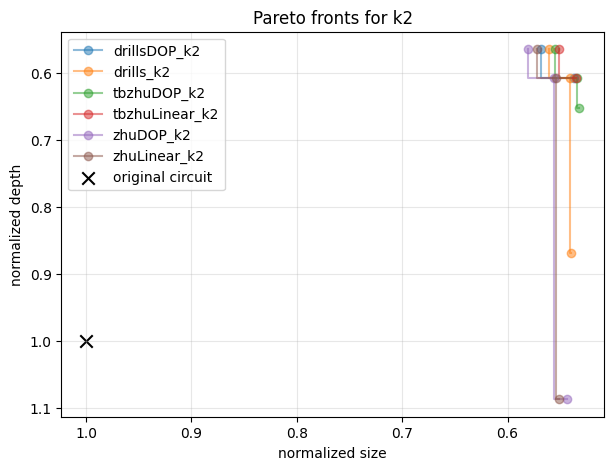

In [9]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(7, 5))

for run_name in selected_experiments:
    front = selected_front_df[selected_front_df["run_name"] == run_name].sort_values(
        ["normalized_size", "normalized_depth"]
    )
    if front.empty:
        continue
    ax.step(
        front["normalized_size"],
        front["normalized_depth"],
        where="post",
        marker="o",
        alpha=0.5,
        label=run_name,
    )

ax.scatter([1.0], [1.0], marker="x", s=80, color="black", label="original circuit")
ax.set_xlabel("normalized size")
ax.set_ylabel("normalized depth")
ax.set_title(f"Pareto fronts for {Path(selected_circuit).name}")
ax.grid(True, alpha=0.3)
ax.legend()
ax.invert_xaxis()
ax.invert_yaxis()
plt.show()